# 03 — Preprocessing Pipeline and Baseline Modeling

Phase 3 builds a reproducible, leakage-safe preprocessing pipeline and compares:

- A prior-based dummy classifier.
- Class-weighted logistic regression.
- A logistic-regression ablation without the high-drift features identified in Phase 2.

Guardrails:

- Preprocessing is fit on months 0–4 only.
- Month 5 is used for initial calibration diagnostics.
- Month 6 is used for baseline comparison.
- Month 7 remains reserved and is not exposed to the experiment object.
- The `0.50` cutoff is diagnostic only, not a selected business threshold.
- No calibrated model or final threshold is selected in this notebook.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import display

from fraudshield.config import load_config, resolve_project_path
from fraudshield.evaluate import (
    build_error_analysis_frame,
    calibration_table,
)
from fraudshield.train import (
    logistic_coefficient_frame,
    positive_class_probability,
    run_baseline_experiment,
)

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda value: f"{value:.6f}")
sns.set_theme(style="whitegrid")

PROJECT_ROOT = Path.cwd().resolve()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

CONFIG_PATH = PROJECT_ROOT / "configs" / "base.yaml"

if not CONFIG_PATH.is_file():
    raise FileNotFoundError(
        "Run this notebook from the FraudShield repository or notebooks directory."
    )

print(f"Project root: {PROJECT_ROOT}")
print(f"Config: {CONFIG_PATH}")

Project root: D:\latihan\fraudshield
Config: D:\latihan\fraudshield\configs\base.yaml


## 1. Configuration audit

The rules below are fixed before model fitting. Sentinel conversion is domain-defined; medians, scaling statistics, and one-hot categories are learned by the estimator pipeline from training rows only.

In [2]:
config = load_config(CONFIG_PATH)
raw_dataset_path = resolve_project_path(
    config["data"]["raw_path"],
    config_path=CONFIG_PATH,
)

configuration_summary = {
    "raw_dataset_path": str(raw_dataset_path),
    "train_periods": config["split"]["train_periods"],
    "calibration_periods": config["split"]["calibration_periods"],
    "validation_periods": config["split"]["validation_periods"],
    "reserved_test_periods": config["split"]["test_periods"],
    "excluded_features": config["feature_policy"]["excluded_from_model"],
    "categorical_features": config["preprocessing"]["categorical_features"],
    "semantic_missing_rules": config["preprocessing"]["semantic_missing_rules"],
    "review_rates": config["evaluation"]["review_rates"],
}

configuration_summary

{'raw_dataset_path': 'D:\\latihan\\fraudshield\\data\\raw\\Base.csv',
 'train_periods': [0, 1, 2, 3, 4],
 'calibration_periods': [5],
 'validation_periods': [6],
 'reserved_test_periods': [7],
 'excluded_features': ['fraud_bool',
  'month',
  'device_fraud_count',
  'days_since_request',
  'credit_risk_score'],
 'categorical_features': ['payment_type',
  'employment_status',
  'housing_status',
  'source',
  'device_os'],
 'semantic_missing_rules': {'prev_address_months_count': {'operator': 'equals',
   'value': -1},
  'current_address_months_count': {'operator': 'equals', 'value': -1},
  'bank_months_count': {'operator': 'equals', 'value': -1},
  'session_length_in_minutes': {'operator': 'equals', 'value': -1},
  'device_distinct_emails_8w': {'operator': 'equals', 'value': -1},
  'intended_balcon_amount': {'operator': 'less_than', 'value': 0}},
 'review_rates': [0.01, 0.03, 0.05, 0.1]}

## 2. Run the development-only baseline experiment

This cell validates the complete raw schema, creates the chronological split, fits every model on train, evaluates only calibration and validation, and saves ignored local artifacts under `artifacts/phase3/`.

The full one-million-row dataset can take several minutes on a laptop. Do not interrupt the kernel while a model is fitting.

In [3]:
result = run_baseline_experiment(
    CONFIG_PATH,
    save_artifacts=True,
)

development_data = result.development_data

split_summary = pd.DataFrame(
    {
        "split": ["train", "calibration", "validation", "test_reserved"],
        "rows": [
            len(development_data.train_features),
            len(development_data.calibration_features),
            len(development_data.validation_features),
            development_data.reserved_test_rows,
        ],
        "exposed_to_phase3_modeling": [True, True, True, False],
    }
)

display(split_summary)
print(
    "Test features available on experiment object:",
    hasattr(development_data, "test_features"),
)
print("Models:", list(result.models))
print("Training seconds:", result.training_seconds)

,split,rows,exposed_to_phase3_modeling
0,train,675666,True
1,calibration,119323,True
2,validation,108168,True
3,test_reserved,96843,False


Test features available on experiment object: False
Models: ['dummy_prior', 'logistic_regression_balanced', 'logistic_regression_without_high_drift']
Training seconds: {'dummy_prior': 0.06011000002035871, 'logistic_regression_balanced': 13.477712099964265, 'logistic_regression_without_high_drift': 10.597060400003102}


## 3. Baseline probability metrics

`pr_auc_average_precision` is the primary discrimination summary. ROC-AUC is secondary. Brier score and expected calibration error diagnose raw probability quality; the weighted logistic probabilities are not treated as calibrated probabilities.

In [4]:
metric_records = []

for model_name, split_metrics in result.metrics.items():
    for split_name, metrics in split_metrics.items():
        metric_records.append(
            {
                "model": model_name,
                "split": split_name,
                "rows": metrics["row_count"],
                "prevalence": metrics["prevalence"],
                "pr_auc_average_precision": metrics[
                    "pr_auc_average_precision"
                ],
                "roc_auc": metrics["roc_auc"],
                "brier_score": metrics["brier_score"],
                "log_loss": metrics["log_loss"],
                "expected_calibration_error": metrics[
                    "expected_calibration_error"
                ],
            }
        )

baseline_metrics = pd.DataFrame(metric_records).sort_values(
    ["split", "pr_auc_average_precision"],
    ascending=[True, False],
    ignore_index=True,
)

display(baseline_metrics)

,model,split,rows,prevalence,pr_auc_average_precision,roc_auc,brier_score,log_loss,expected_calibration_error
0,logistic_regression_balanced,calibration,119323,0.011825,0.152822,0.882157,0.105151,0.341282,0.224318
1,logistic_regression_without_high_drift,calibration,119323,0.011825,0.151998,0.881549,0.131753,0.414137,0.265319
2,dummy_prior,calibration,119323,0.011825,0.011825,0.500000,0.011689,0.064392,0.001850
3,logistic_regression_balanced,validation,108168,0.013405,0.151703,0.880599,0.112137,0.359370,0.231547
4,logistic_regression_without_high_drift,validation,108168,0.013405,0.150822,0.880760,0.144449,0.447896,0.279906
5,dummy_prior,validation,108168,0.013405,0.013405,0.500000,0.013237,0.071657,0.003430


## 4. Review-capacity metrics

Applications are ranked by predicted probability. Each configured rate represents a hypothetical manual-review capacity, not a chosen production policy.

,model,requested_review_rate,actual_review_rate,review_count,precision_at_capacity,recall_at_capacity,fraud_capture_rate,score_cutoff
0,dummy_prior,0.010000,0.010003,1082,0.013405,0.010003,0.010003,0.009975
1,dummy_prior,0.030000,0.030009,3246,0.013405,0.030009,0.030009,0.009975
2,dummy_prior,0.050000,0.050006,5409,0.013405,0.050006,0.050006,0.009975
3,dummy_prior,0.100000,0.100002,10817,0.013405,0.100002,0.100002,0.009975
4,logistic_regression_balanced,0.010000,0.010003,1082,0.243993,0.182069,0.182069,0.918104
5,logistic_regression_balanced,0.030000,0.030009,3246,0.158349,0.354483,0.354483,0.840701
6,logistic_regression_balanced,0.050000,0.050006,5409,0.126826,0.473103,0.473103,0.771853
7,logistic_regression_balanced,0.100000,0.100002,10817,0.082648,0.616552,0.616552,0.632526
8,logistic_regression_without_high_drift,0.010000,0.010003,1082,0.249538,0.186207,0.186207,0.939274
9,logistic_regression_without_high_drift,0.030000,0.030009,3246,0.160505,0.359310,0.359310,0.878763


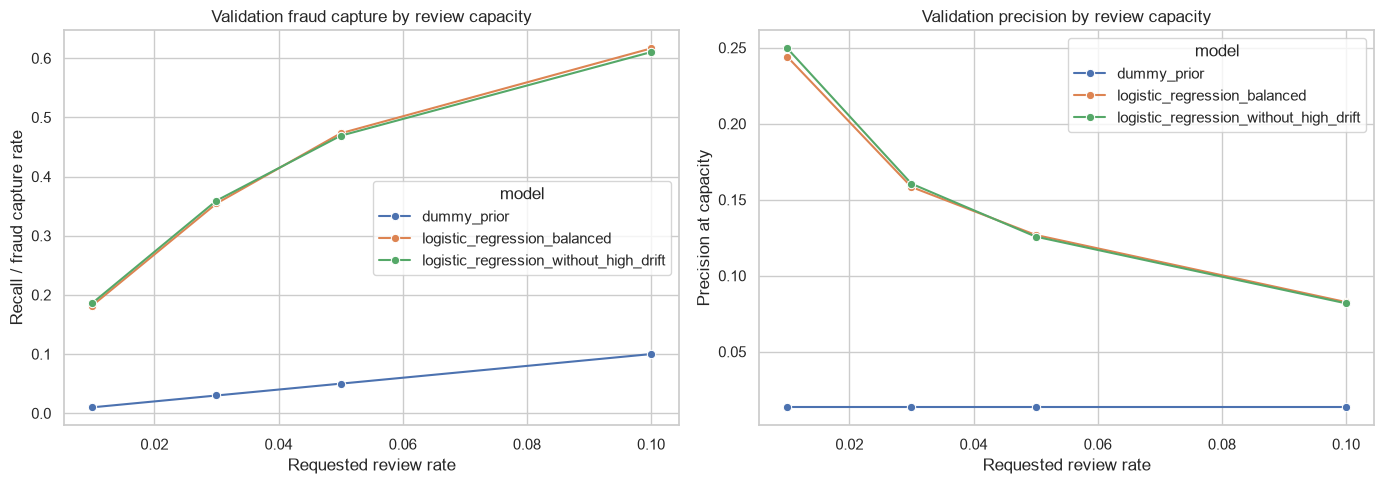

In [5]:
review_records = []

for model_name, split_metrics in result.metrics.items():
    validation_metrics = split_metrics["validation"]

    for capacity_key, capacity_metrics in validation_metrics[
        "review_rate_metrics"
    ].items():
        review_records.append(
            {
                "model": model_name,
                "requested_review_rate": capacity_metrics[
                    "requested_review_rate"
                ],
                "actual_review_rate": capacity_metrics[
                    "actual_review_rate"
                ],
                "review_count": capacity_metrics["review_count"],
                "precision_at_capacity": capacity_metrics[
                    "precision_at_capacity"
                ],
                "recall_at_capacity": capacity_metrics[
                    "recall_at_capacity"
                ],
                "fraud_capture_rate": capacity_metrics[
                    "fraud_capture_rate"
                ],
                "score_cutoff": capacity_metrics["score_cutoff"],
            }
        )

review_metrics = pd.DataFrame(review_records)
display(review_metrics)

figure, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.lineplot(
    data=review_metrics,
    x="requested_review_rate",
    y="recall_at_capacity",
    hue="model",
    marker="o",
    ax=axes[0],
)
axes[0].set_title("Validation fraud capture by review capacity")
axes[0].set_xlabel("Requested review rate")
axes[0].set_ylabel("Recall / fraud capture rate")

sns.lineplot(
    data=review_metrics,
    x="requested_review_rate",
    y="precision_at_capacity",
    hue="model",
    marker="o",
    ax=axes[1],
)
axes[1].set_title("Validation precision by review capacity")
axes[1].set_xlabel("Requested review rate")
axes[1].set_ylabel("Precision at capacity")

plt.tight_layout()
plt.show()

## 5. Initial calibration diagnostics

These plots evaluate the raw model probabilities. Platt scaling and isotonic regression are intentionally deferred to the dedicated calibration phase.

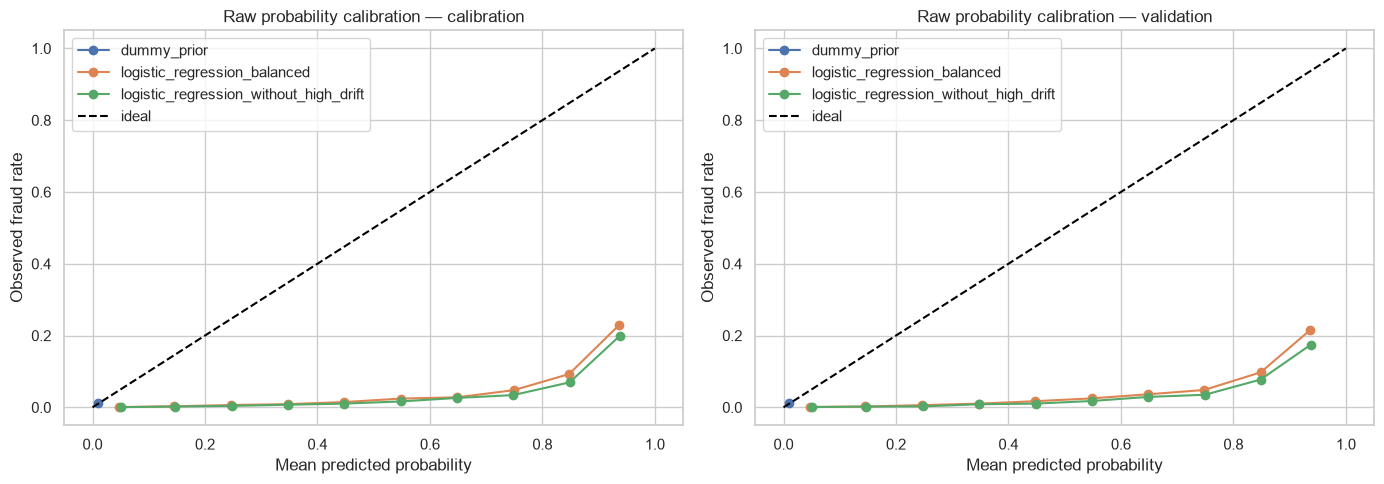

In [6]:
figure, axes = plt.subplots(1, 2, figsize=(14, 5))

for axis, split_name, features, target in [
    (
        axes[0],
        "calibration",
        development_data.calibration_features,
        development_data.calibration_target,
    ),
    (
        axes[1],
        "validation",
        development_data.validation_features,
        development_data.validation_target,
    ),
]:
    for model_name, model in result.models.items():
        probabilities = positive_class_probability(model, features)
        table = calibration_table(
            target,
            probabilities,
            number_of_bins=config["evaluation"]["calibration_bins"],
        )
        axis.plot(
            table["mean_predicted_probability"],
            table["observed_fraud_rate"],
            marker="o",
            label=model_name,
        )

    axis.plot([0, 1], [0, 1], linestyle="--", color="black", label="ideal")
    axis.set_title(f"Raw probability calibration — {split_name}")
    axis.set_xlabel("Mean predicted probability")
    axis.set_ylabel("Observed fraud rate")
    axis.legend()

plt.tight_layout()
plt.show()

## 6. Diagnostic confusion matrix and error samples

The configured `0.50` cutoff is used only to make baseline error modes inspectable. It must not be copied into the review policy as a selected threshold.

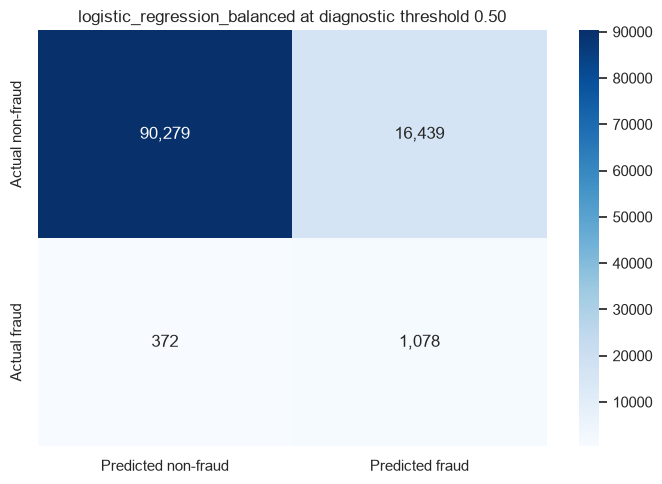

error_type
false_positive    20
false_negative    20
Name: shown_examples, dtype: int64

,source_index,target,fraud_probability,diagnostic_prediction,error_type,income,customer_age,payment_type,employment_status,housing_status,source
0,553567,0,0.994791,1,false_positive,0.900000,60,AC,CC,BA,INTERNET
1,575064,0,0.992056,1,false_positive,0.900000,60,AC,CC,BA,INTERNET
2,612862,0,0.991318,1,false_positive,0.900000,60,AB,CC,BA,INTERNET
3,549102,0,0.990852,1,false_positive,0.900000,50,AC,CB,BA,TELEAPP
4,586799,0,0.990270,1,false_positive,0.900000,60,AB,CC,BA,INTERNET
5,560074,0,0.988229,1,false_positive,0.900000,60,AA,CA,BA,INTERNET
6,586392,0,0.987376,1,false_positive,0.600000,40,AC,CA,BA,INTERNET
7,525300,0,0.986510,1,false_positive,0.900000,50,AD,CA,BA,INTERNET
8,568699,0,0.986410,1,false_positive,0.900000,30,AC,CA,BA,INTERNET
9,601188,0,0.984982,1,false_positive,0.900000,40,AC,CA,BA,INTERNET


In [7]:
primary_model_name = config["baseline"]["primary_model_name"]
primary_model = result.models[primary_model_name]
primary_validation_metrics = result.metrics[primary_model_name]["validation"]
confusion = primary_validation_metrics["diagnostic_confusion_matrix"]
confusion_frame = pd.DataFrame(
    [
        [confusion["true_negative"], confusion["false_positive"]],
        [confusion["false_negative"], confusion["true_positive"]],
    ],
    index=["Actual non-fraud", "Actual fraud"],
    columns=["Predicted non-fraud", "Predicted fraud"],
)

figure, axis = plt.subplots(figsize=(7, 5))
sns.heatmap(confusion_frame, annot=True, fmt=",d", cmap="Blues", ax=axis)
axis.set_title(
    f"{primary_model_name} at diagnostic threshold "
    f"{config['evaluation']['diagnostic_threshold']:.2f}"
)
plt.tight_layout()
plt.show()

primary_validation_probabilities = positive_class_probability(
    primary_model,
    development_data.validation_features,
)
error_examples = build_error_analysis_frame(
    development_data.validation_features,
    development_data.validation_target,
    primary_validation_probabilities,
    diagnostic_threshold=config["evaluation"]["diagnostic_threshold"],
    examples_per_error_type=20,
)

display(error_examples["error_type"].value_counts().rename("shown_examples"))
display(
    error_examples[
        [
            "source_index",
            "target",
            "fraud_probability",
            "diagnostic_prediction",
            "error_type",
            "income",
            "customer_age",
            "payment_type",
            "employment_status",
            "housing_status",
            "source",
        ]
    ]
)

## 7. Logistic-regression coefficient audit

Coefficients are associations on transformed features, not causal explanations. They are included to verify feature lineage and provide an interpretable baseline before SHAP analysis in a later phase.

,feature,coefficient,absolute_coefficient
0,source_INTERNET,-1.452045,1.452045
1,device_os_linux,-1.197406,1.197406
2,source_TELEAPP,-0.974954,0.974954
3,employment_status_CF,-0.974743,0.974743
4,housing_status_BE,-0.901855,0.901855
5,device_os_other,-0.883485,0.883485
6,employment_status_CE,-0.747385,0.747385
7,prev_address_months_count__missing,0.702699,0.702699
8,housing_status_BB,-0.654199,0.654199
9,payment_type_AB,-0.633654,0.633654


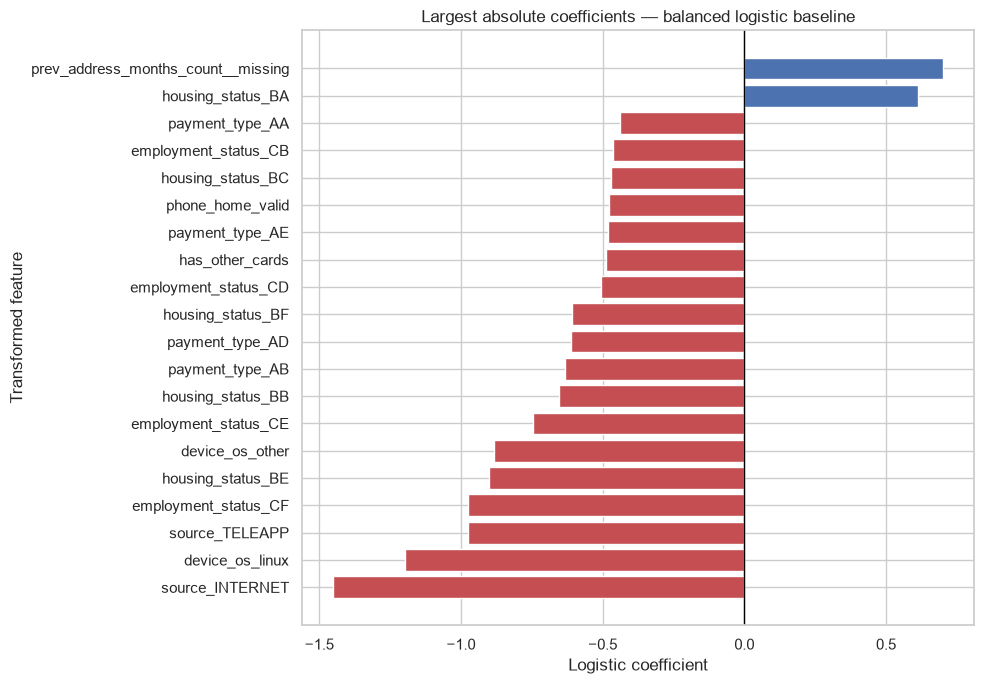

In [8]:
coefficient_frame = logistic_coefficient_frame(primary_model)
display(coefficient_frame.head(25))

top_coefficients = coefficient_frame.head(20).sort_values("coefficient")
colors = ["#c44e52" if value < 0 else "#4c72b0" for value in top_coefficients["coefficient"]]

figure, axis = plt.subplots(figsize=(10, 7))
axis.barh(
    top_coefficients["feature"],
    top_coefficients["coefficient"],
    color=colors,
)
axis.axvline(0, color="black", linewidth=1)
axis.set_title("Largest absolute coefficients — balanced logistic baseline")
axis.set_xlabel("Logistic coefficient")
axis.set_ylabel("Transformed feature")
plt.tight_layout()
plt.show()

## 8. High-drift feature ablation

The ablation removes all features classified as high drift in Phase 2. Compare out-of-time validation performance and calibration; do not remove features based on PSI alone.

In [9]:
ablation_model_name = config["baseline"]["high_drift_ablation"][
    "model_name"
]
comparison_columns = [
    "pr_auc_average_precision",
    "roc_auc",
    "brier_score",
    "expected_calibration_error",
]
ablation_comparison = (
    baseline_metrics.loc[
        (baseline_metrics["split"] == "validation")
        & baseline_metrics["model"].isin(
            [primary_model_name, ablation_model_name]
        ),
        ["model", *comparison_columns],
    ]
    .set_index("model")
)

display(ablation_comparison)

ablation_delta = (
    ablation_comparison.loc[ablation_model_name]
    - ablation_comparison.loc[primary_model_name]
).rename("ablation_minus_primary")

display(ablation_delta.to_frame())

,pr_auc_average_precision,roc_auc,brier_score,expected_calibration_error
model,,,,
logistic_regression_balanced,0.151703,0.880599,0.112137,0.231547
logistic_regression_without_high_drift,0.150822,0.880760,0.144449,0.279906


,ablation_minus_primary
pr_auc_average_precision,-0.000881
roc_auc,0.000161
brier_score,0.032312
expected_calibration_error,0.048360


## 9. Saved artifacts and Phase 3 decision record

The files below are local experiment outputs and remain ignored by Git. Commit the source, configuration, notebook, and tests—not the fitted model binaries.

Before completing Phase 3, record the actual observed results in the project report. Do not claim a final production model, calibrated probability, selected threshold, cost saving, or untouched-test performance yet.

In [10]:
artifact_table = pd.DataFrame(
    [
        {"artifact": name, "path": str(path)}
        for name, path in result.artifact_paths.items()
    ]
)

display(artifact_table)

phase3_checks = {
    "test_evaluated": False,
    "test_features_exposed": hasattr(development_data, "test_features"),
    "preprocessing_fitted_inside_model_pipeline": True,
    "unknown_categories_ignored": True,
    "semantic_missing_indicators_enabled": config["preprocessing"][
        "add_missing_indicators"
    ],
    "business_threshold_selected": False,
    "probability_calibrator_selected": False,
}

phase3_checks

,artifact,path
0,model:dummy_prior,D:\latihan\fraudshield\artifacts\phase3\dummy_...
1,model:logistic_regression_balanced,D:\latihan\fraudshield\artifacts\phase3\logist...
2,model:logistic_regression_without_high_drift,D:\latihan\fraudshield\artifacts\phase3\logist...
3,metrics,D:\latihan\fraudshield\artifacts\phase3\baseli...
4,validation_errors,D:\latihan\fraudshield\artifacts\phase3\valida...
5,coefficients:logistic_regression_balanced,D:\latihan\fraudshield\artifacts\phase3\logist...
6,coefficients:logistic_regression_without_high_...,D:\latihan\fraudshield\artifacts\phase3\logist...
7,metadata,D:\latihan\fraudshield\artifacts\phase3\baseli...


{'test_evaluated': False,
 'test_features_exposed': False,
 'preprocessing_fitted_inside_model_pipeline': True,
 'unknown_categories_ignored': True,
 'semantic_missing_indicators_enabled': True,
 'business_threshold_selected': False,
 'probability_calibrator_selected': False}

### Phase 3 interpretation checklist

After a clean restart and Run All, answer using the displayed evidence:

1. Does balanced logistic regression improve validation average precision and recall-at-capacity over the dummy baseline?
2. How much do raw probability calibration metrics differ between months 5 and 6?
3. Does removing the high-drift feature group improve or reduce validation ranking performance?
4. Which false-positive and false-negative patterns deserve slice analysis later?
5. Are any convergence warnings present?

Keep month 7 untouched. Final model selection occurs only after the constrained Phase 4 comparison, and calibration/threshold selection occurs in Phase 5.

## Phase 3 conclusion

The leakage-safe baseline experiment completed successfully without exposing
test features or labels.

On month 6 validation, class-weighted logistic regression achieved an average
precision of 0.151703 and ROC-AUC of 0.880599. The dummy baseline achieved an
average precision equal to the 0.013405 validation fraud prevalence.

At review capacities of 1%, 3%, 5%, and 10%, the primary logistic baseline
captured 18.21%, 35.45%, 47.31%, and 61.66% of validation fraud, respectively.

The high-drift ablation performed slightly better at 1% and 3% capacity, while
the primary model performed slightly better at 5%, 10%, and overall average
precision. High-drift features remain in the primary baseline but require
continued monitoring.

The raw class-weighted probabilities are not calibrated. The diagnostic 0.50
cutoff produced 1,078 true positives, 372 false negatives, 16,439 false
positives, and 90,279 true negatives. It would review approximately 16.19% of
validation applications and is not adopted as an operational threshold.

Month 7 remains untouched. Final model selection, probability calibration, and
business-threshold selection are deferred to later phases.
